<a href="https://colab.research.google.com/github/Arooba93/Health-tracker/blob/main/torch_vision_using_pretrained__model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
from google.colab import drive

# 1. Connect to Google Drive
drive.mount('/content/drive')

# 2. Extract the zip file to Colab's local disk
zip_path = '/content/drive/MyDrive/archive.zip' # Update if your zip has a different name
extract_dir = '/content/medical_data'

print("Extracting files... please wait.")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 3. VERIFY: Count the images to make sure it worked
train_normal = len(os.listdir('/content/medical_data/chest_xray/train/NORMAL'))
train_pneumonia = len(os.listdir('/content/medical_data/chest_xray/train/PNEUMONIA'))

print("\n--- Extraction Complete ---")
print(f"Normal X-Rays found: {train_normal}")
print(f"Pneumonia X-Rays found: {train_pneumonia}")

Mounted at /content/drive
Extracting files... please wait.

--- Extraction Complete ---
Normal X-Rays found: 1341
Pneumonia X-Rays found: 3875


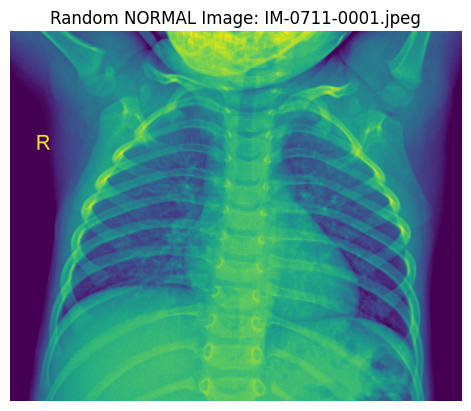

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Define the directory for NORMAL images
normal_dir = os.path.join(extract_dir, 'chest_xray', 'train', 'NORMAL')
normal_images = os.listdir(normal_dir)

# Select a random image in the NORMAL folder
if normal_images:
    random_image_name = random.choice(normal_images)
    random_normal_image_path = os.path.join(normal_dir, random_image_name)
    img = Image.open(random_normal_image_path)
    plt.imshow(img)
    plt.title(f"Random NORMAL Image: {random_image_name}")
    plt.axis('off')
    plt.show()
else:
    print("No images found in the NORMAL folder.")

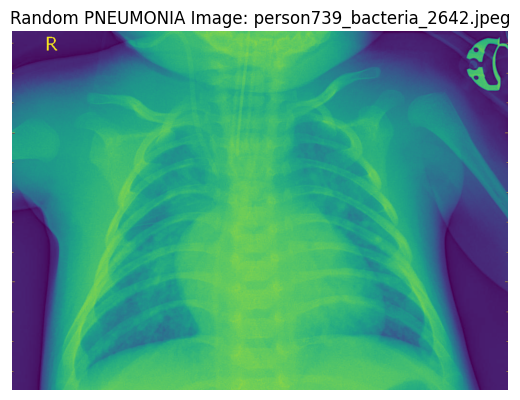

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Define the directory for PNEUMONIA images
pneumonia_dir = os.path.join(extract_dir, 'chest_xray', 'train', 'PNEUMONIA')
pneumonia_images = os.listdir(pneumonia_dir)

# Select a random image in the PNEUMONIA folder
if pneumonia_images:
    random_image_name = random.choice(pneumonia_images)
    random_pneumonia_image_path = os.path.join(pneumonia_dir, random_image_name)
    img = Image.open(random_pneumonia_image_path)
    plt.imshow(img)
    plt.title(f"Random PNEUMONIA Image: {random_image_name}")
    plt.axis('off')
    plt.show()
else:
    print("No images found in the PNEUMONIA folder.")


--- Data Loader Ready ---
Classes: ['NORMAL', 'PNEUMONIA'] | Processing on: cuda:0


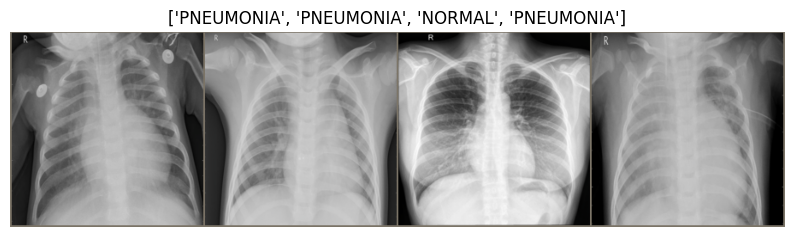

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Rules for processing the images
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Create the loaders (Train for learning, Test for the final exam)
base_dir = '/content/medical_data/chest_xray'
train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), data_transforms)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 3. VERIFY: Plot one batch of images to the screen
print(f"\n--- Data Loader Ready ---")
print(f"Classes: {class_names} | Processing on: {device}")

inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])

# Reverse the normalization just so our human eyes can see it clearly
inp = out.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
inp = np.clip(std * inp + mean, 0, 1)

plt.figure(figsize=(10, 4))
plt.imshow(inp)
plt.title([class_names[x] for x in classes[:4]])
plt.axis('off')
plt.show()

Adam is adaptive optimizer as opose to SGD that can get very slow and take smaller leaps as grafient platoes

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 123MB/s]



--- Model A ---


Epoch 1/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/9 | Training Loss: 0.1791
Epoch 1/9 | Test Accuracy: 81.57%


...

Epoch 7/9 | Training Loss: 0.0637
Epoch 7/9 | Test Accuracy: 83.97%


Epoch 8/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 8/9 | Training Loss: 0.0614
Epoch 8/9 | Test Accuracy: 86.22%


Epoch 9/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 9/9 | Training Loss: 0.0580
Epoch 9/9 | Test Accuracy: 82.85%


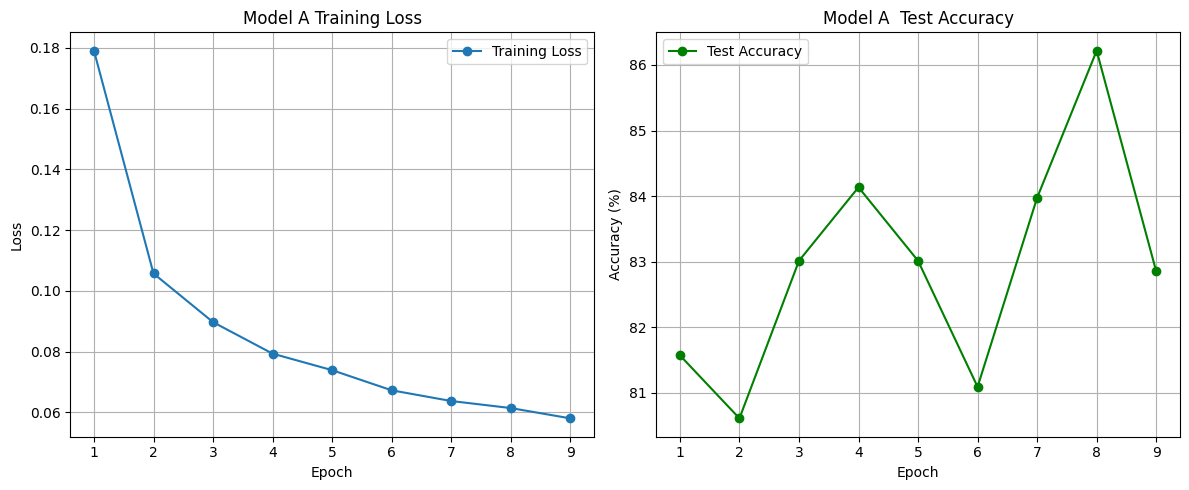

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Import tqdm for the progress bar

# 1. Download model and freeze the core layers
model_A = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
for param in model_A.parameters():
    param.requires_grad = False

# 2. Swap the final layer to predict 2 classes instead of 1000
in_features = model_A.heads.head.in_features
model_A.heads.head = nn.Linear(in_features, 2)
model_A = model_A.to(device)

# 3. Setup optimizer (only updating the head)
criterion = nn.CrossEntropyLoss()
optimizer_A = optim.Adam(model_A.heads.head.parameters(), lr=0.001)

print("\n--- Model A ---")
model_A.train()
history_A = [] # To store training loss
history_accuracy_A = [] # To store test accuracy

num_epochs = 9
 # Define number of epochs for easier modification

for epoch in range(num_epochs): # Loop for specified number of epochs
    running_loss = 0.0
    # Add tqdm for a progress bar for each epoch
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_A.zero_grad()

        outputs = model_A(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_A.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    history_A.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")

    # Calculate accuracy on the test set after each epoch
    model_A.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_A(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_accuracy = 100 * correct / total
    history_accuracy_A.append(epoch_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs} | Test Accuracy: {epoch_accuracy:.2f}%")
    model_A.train() # Set model back to training mode

# VERIFY: Plot learning progress (training loss and test accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot for Loss
plt.plot(range(1, num_epochs + 1), history_A, marker='o', label="Training Loss")
plt.title("Model A Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot for Accuracy
plt.plot(range(1, num_epochs + 1), history_accuracy_A, marker='o', label="Test Accuracy", color='green')
plt.title("Model A  Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


--- Model B ---


Model B Epoch 1/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model B Epoch 1/9 | Training Loss: 0.0738
Model B Epoch 1/9 | Test Accuracy: 88.94%


Model B Epoch 2/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model B Epoch 2/9 | Training Loss: 0.0210
Model B Epoch 2/9 | Test Accuracy: 81.09%


...

Model B Epoch 7/9 | Training Loss: 0.0001
Model B Epoch 7/9 | Test Accuracy: 83.49%


Model B Epoch 8/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model B Epoch 8/9 | Training Loss: 0.0001
Model B Epoch 8/9 | Test Accuracy: 83.01%


Model B Epoch 9/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model B Epoch 9/9 | Training Loss: 0.0001
Model B Epoch 9/9 | Test Accuracy: 83.49%


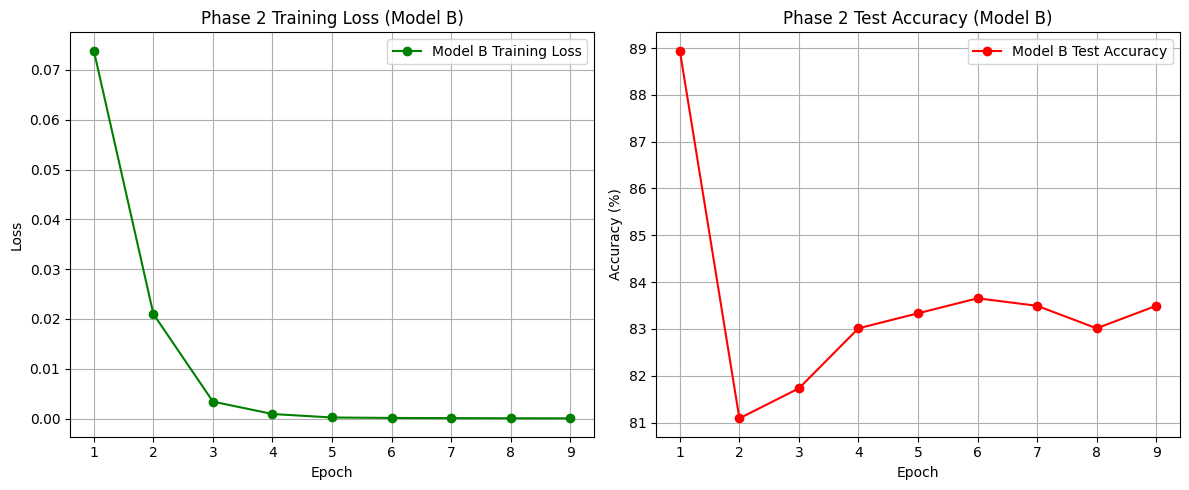

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Import tqdm for the progress bar
import copy

print("\n--- Model B ---")

# 1. Clone Model A to create Model B
model_B = copy.deepcopy(model_A)

# 2. Unfreeze EVERYTHING in Model B
for param in model_B.parameters():
    param.requires_grad = True

# 3. Use a much smaller learning rate so we don't break the pre-trained weights
optimizer_B = optim.Adam(model_B.parameters(), lr=1e-5)

model_B.train()
history_B = [] # To store training loss
history_accuracy_B = [] # To store test accuracy

num_epochs_B = 9 # Define number of epochs for easier modification for Model B

for epoch in range(num_epochs_B):
    running_loss = 0.0
    # Add tqdm for a progress bar for each epoch
    for inputs, labels in tqdm(train_loader, desc=f"Model B Epoch {epoch+1}/{num_epochs_B}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_B.zero_grad()

        outputs = model_B(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_B.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    history_B.append(epoch_loss)
    print(f"Model B Epoch {epoch+1}/{num_epochs_B} | Training Loss: {epoch_loss:.4f}")

    # Calculate accuracy on the test set after each epoch for Model B
    model_B.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_B(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_accuracy = 100 * correct / total
    history_accuracy_B.append(epoch_accuracy)
    print(f"Model B Epoch {epoch+1}/{num_epochs_B} | Test Accuracy: {epoch_accuracy:.2f}%")
    model_B.train() # Set model back to training mode

# VERIFY: Plot learning progress (training loss and test accuracy for Model B)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot for Loss
plt.plot(range(1, num_epochs_B + 1), history_B, marker='o', color='green', label="Model B Training Loss")
plt.title("Phase 2 Training Loss (Model B)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot for Accuracy
plt.plot(range(1, num_epochs_B + 1), history_accuracy_B, marker='o', color='red', label="Model B Test Accuracy")
plt.title("Phase 2 Test Accuracy (Model B)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Final Evaluation on Unseen Test Data ---")
# Set both models to evaluation mode (turns off training features like dropout)
model_A.eval()
model_B.eval()

# A helper function to test a model and calculate its accuracy score
def evaluate_model(model_to_test):
    correct = 0
    total = 0
    with torch.no_grad(): # Tell PyTorch we are just guessing, not learning
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_to_test(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100

# 1. Give both models the final exam
acc_A = evaluate_model(model_A)
print(f"Model A - Test Accuracy: {acc_A:.2f}%")

acc_B = evaluate_model(model_B)
print(f"Model B - Test Accuracy: {acc_B:.2f}%")

# 2. Define exactly where to save them in your Google Drive
save_path_A = '/content/drive/MyDrive/model_A_pneumonia.pth'
save_path_B = '/content/drive/MyDrive/model_B_pneumonia.pth'

# 3. Save both models
print("\n--- Saving Models to Google Drive ---")
torch.save(model_A.state_dict(), save_path_A)
print(f"✅ Model A successfully saved to: {save_path_A}")

torch.save(model_B.state_dict(), save_path_B)
print(f"✅ Model B successfully saved to: {save_path_B}")

print("\nAll done! Both models are now saved in Google Drive.")


--- Final Evaluation on Unseen Test Data ---
Model A - Test Accuracy: 82.85%
Model B - Test Accuracy: 83.49%

--- Saving Models to Google Drive ---
✅ Model A successfully saved to: /content/drive/MyDrive/model_A_pneumonia.pth
✅ Model B successfully saved to: /content/drive/MyDrive/model_B_pneumonia.pth

All done! Both models are now saved in Google Drive.


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Re-establish paths and device
base_dir = '/content/medical_data/chest_xray'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 2. Re-create transforms and datasets
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), data_transforms)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Calculate Class Weights for Model C
normal_count = train_dataset.targets.count(0)
pneumonia_count = train_dataset.targets.count(1)
total_samples = normal_count + pneumonia_count

weight_normal = total_samples / normal_count
weight_pneumonia = total_samples / pneumonia_count
class_weights = torch.tensor([weight_normal, weight_pneumonia], dtype=torch.float).to(device)

print(f"Data Loaded Successfully on {device}!")
print(f"Normal: {normal_count} images (Penalty weight: {weight_normal:.2f}x)")
print(f"Pneumonia: {pneumonia_count} images (Penalty weight: {weight_pneumonia:.2f}x)")

Data Loaded Successfully on cuda:0!
Normal: 1341 images (Penalty weight: 3.89x)
Pneumonia: 3875 images (Penalty weight: 1.35x)


Initializing Model C...
Starting Training...

Epoch 1/9 | LR: 0.000010


Model C Epoch 1/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model C Epoch 1/9 | Training Loss: 0.1271
Model C Epoch 1/9 | Test Accuracy: 87.66%

Epoch 2/9 | LR: 0.000010


Model C Epoch 2/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model C Epoch 2/9 | Training Loss: 0.0382
Model C Epoch 2/9 | Test Accuracy: 81.57%

Epoch 3/9 | LR: 0.000005


...

Model C Epoch 7/9 | Training Loss: 0.0005
Model C Epoch 7/9 | Test Accuracy: 81.41%

Epoch 8/9 | LR: 0.000001


Model C Epoch 8/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model C Epoch 8/9 | Training Loss: 0.0005
Model C Epoch 8/9 | Test Accuracy: 81.57%

Epoch 9/9 | LR: 0.000001


Model C Epoch 9/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model C Epoch 9/9 | Training Loss: 0.0004
Model C Epoch 9/9 | Test Accuracy: 81.41%


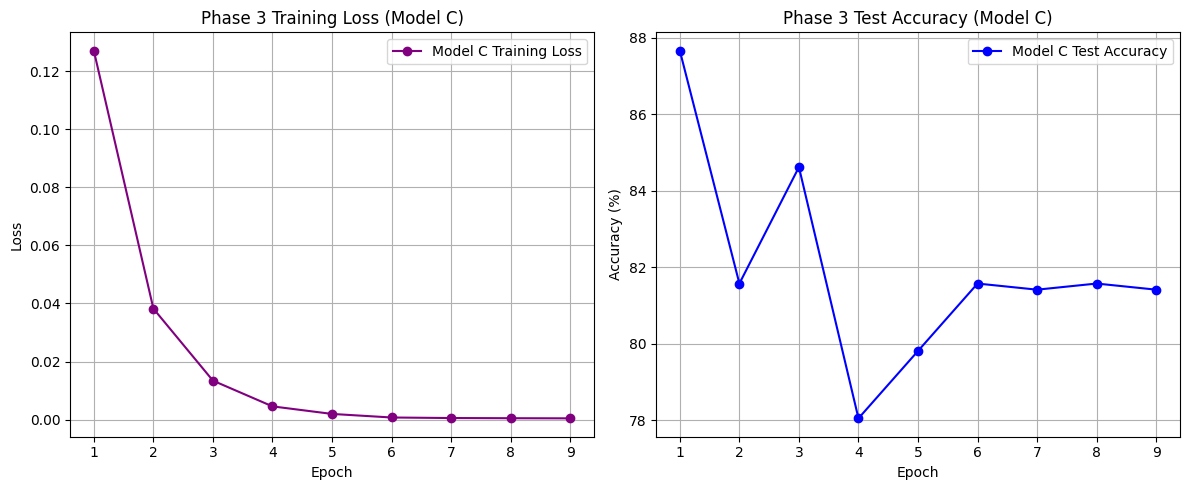

In [ ]:
import torchvision.models as models
import torch.optim as optim
from torch.optim import lr_scheduler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Import tqdm for the progress bar

print("Initializing Model C...")
# 1. Setup the Model
model_C = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
in_features = model_C.heads.head.in_features
model_C.heads.head = nn.Linear(in_features, 2)
model_C = model_C.to(device)

# 2. Setup Weighted Loss, Optimizer, and Scheduler
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)
optimizer_C = optim.Adam(model_C.parameters(), lr=1e-5)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_C, step_size=2, gamma=0.5)

print("Starting Training...")
model_C.train()
history_C = [] # To store training loss
history_accuracy_C = [] # To store test accuracy
num_epochs = 9

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs} | LR: {optimizer_C.param_groups[0]["lr"]:.6f}')

    running_loss = 0.0

    # Add tqdm for a progress bar for each epoch
    for inputs, labels in tqdm(train_loader, desc=f"Model C Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_C.zero_grad()

        outputs = model_C(inputs)
        loss = criterion_weighted(outputs, labels)

        loss.backward()
        optimizer_C.step()
        running_loss += loss.item() * inputs.size(0)

    # Step the scheduler at the end of the epoch
    exp_lr_scheduler.step()

    epoch_loss = running_loss / len(train_dataset)
    history_C.append(epoch_loss)
    print(f"Model C Epoch {epoch+1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")

    # Calculate accuracy on the test set after each epoch for Model C
    model_C.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_C(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_accuracy = 100 * correct / total
    history_accuracy_C.append(epoch_accuracy)
    print(f"Model C Epoch {epoch+1}/{num_epochs} | Test Accuracy: {epoch_accuracy:.2f}%")
    model_C.train() # Set model back to training mode

# Plot the results (training loss and test accuracy for Model C)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot for Loss
plt.plot(range(1, num_epochs + 1), history_C, marker='o', color='purple', label="Model C Training Loss")
plt.title("Phase 3 Training Loss (Model C)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot for Accuracy
plt.plot(range(1, num_epochs + 1), history_accuracy_C, marker='o', color='blue', label="Model C Test Accuracy")
plt.title("Phase 3 Test Accuracy (Model C)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Final Evaluation for Model C ---")
model_C.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_C(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc_C = (correct / total) * 100
print(f"🏆 Model C Test Accuracy: {acc_C:.2f}%")

# Save to Google Drive
save_path_C = '/content/drive/MyDrive/model_C_advanced_pneumonia.pth'
torch.save(model_C.state_dict(), save_path_C)
print(f"✅ Model C successfully saved to: {save_path_C}")


--- Final Evaluation for Model C ---
🏆 Model C Test Accuracy: 81.41%
✅ Model C successfully saved to: /content/drive/MyDrive/model_C_advanced_pneumonia.pth


In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from google.colab import drive

# 1. Smart Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted! Skipping mount step.")

# 2. Re-create the Test DataLoader
base_dir = '/content/medical_data/chest_xray'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), data_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test data ready! Found {len(test_dataset)} images.")

Google Drive is already mounted! Skipping mount step.
Test data ready! Found 624 images.


In [ ]:
def load_model_from_drive(path):
    """Helper function to build a blank ViT and load weights"""
    model = models.vit_b_16(weights=None)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, 2)
    # Load the weights from Drive
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model = model.to(device)
    model.eval() # Turn off training mode
    return model

# Paths to your saved models
path_A = '/content/drive/MyDrive/model_A_pneumonia.pth'
path_B = '/content/drive/MyDrive/model_B_pneumonia.pth'
path_C = '/content/drive/MyDrive/model_C_advanced_pneumonia.pth'

print("Loading models from Google Drive...")
model_A = load_model_from_drive(path_A)
model_B = load_model_from_drive(path_B)
model_C = load_model_from_drive(path_C)
print("All 3 models loaded successfully!")

Loading models from Google Drive...
All 3 models loaded successfully!


In [ ]:
def evaluate_model(model, model_name):
    correct = 0
    total = 0
    print(f"Evaluating {model_name}...")

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = (correct / total) * 100
    return accuracy

print("\n--- Final Head-to-Head Results ---")
acc_A = evaluate_model(model_A, "Model A ")
acc_B = evaluate_model(model_B, "Model B ")
acc_C = evaluate_model(model_C, "Model C ")

print(f"\nModel A Accuracy: {acc_A:.2f}%")
print(f"Model B Accuracy: {acc_B:.2f}%")
print(f"Model C Accuracy: {acc_C:.2f}%")


--- Final Head-to-Head Results ---
Evaluating Model A ...
Evaluating Model B ...
Evaluating Model C ...

Model A Accuracy: 82.85%
Model B Accuracy: 83.49%
Model C Accuracy: 81.41%


### i have learned that Vit is data hungry so at some point its going to over fit

###i want to try one more time with data augmentation

In [ ]:
# 1. Advanced augmentation for training
advanced_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Less extreme cropping for medical images
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # Slight tilt, up to 10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Simulate different X-ray exposures
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Reload the training dataset with the new rules
train_dataset_D = datasets.ImageFolder(os.path.join(base_dir, 'train'), advanced_transforms)
train_loader_D = DataLoader(train_dataset_D, batch_size=32, shuffle=True)

print("Advanced Data Augmentation Ready!")

Advanced Data Augmentation Ready!


In [ ]:
import torchvision.models as models
import torch.nn as nn

print("Initializing Model D...")

# 1. Load the fresh base model
model_D = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
in_features = model_D.heads.head.in_features

# 2. Replace the head with a Sequential block containing Dropout
model_D.heads.head = nn.Sequential(
    nn.Dropout(p=0.5), # 50% probability of dropping a neuron
    nn.Linear(in_features, 2)
)

model_D = model_D.to(device)

Initializing Model D...


In [ ]:
import torch.optim as optim
from torch.optim import lr_scheduler

# 1. Weighted Loss (reusing the weights calculated in Model C)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

# 2. Adam Optimizer with Weight Decay (L2 Regularization)
optimizer_D = optim.Adam(model_D.parameters(), lr=1e-5, weight_decay=1e-4)

# 3. Cosine Annealing Scheduler (smoothly decreases LR over the epochs)

cosine_scheduler = lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=num_epochs)

print("Optimizer with Weight Decay and Cosine Scheduler ready.")

Optimizer with Weight Decay and Cosine Scheduler ready.



Model D Epoch 1/9 | LR: 0.0000100


Model D Epoch 1/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model D Epoch 1/9 | Training Loss: 0.1861
Model D Epoch 1/9 | Test Accuracy: 91.51%

Model D Epoch 2/9 | LR: 0.0000095


Model D Epoch 2/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model D Epoch 2/9 | Training Loss: 0.0894
Model D Epoch 2/9 | Test Accuracy: 91.35%

Model D Epoch 3/9 | LR: 0.0000081


...

Model D Epoch 7/9 | Training Loss: 0.0398
Model D Epoch 7/9 | Test Accuracy: 93.11%

Model D Epoch 8/9 | LR: 0.0000000


Model D Epoch 8/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model D Epoch 8/9 | Training Loss: 0.0411
Model D Epoch 8/9 | Test Accuracy: 93.11%

Model D Epoch 9/9 | LR: 0.0000005


Model D Epoch 9/9:   0%|          | 0/163 [00:00<?, ?it/s]

Model D Epoch 9/9 | Training Loss: 0.0467
Model D Epoch 9/9 | Test Accuracy: 92.15%

--- Final Evaluation for Model D ---
🏆 Model D Test Accuracy: 92.15%
✅ Model D successfully saved to: /content/drive/MyDrive/model_D_regularized_pneumonia.pth


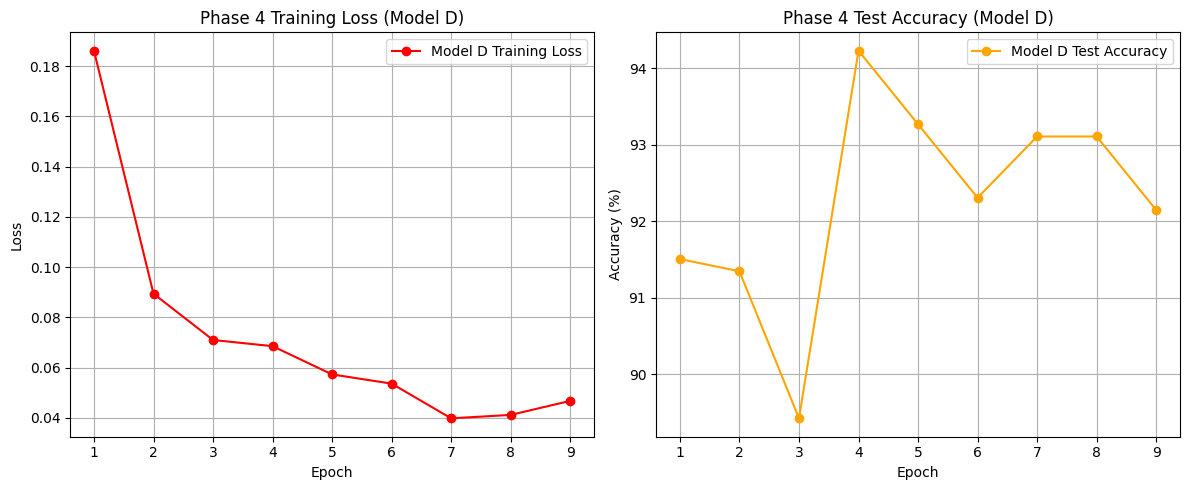

In [ ]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm # Import tqdm for the progress bar

model_D.train()
history_D = [] # To store training loss
history_accuracy_D = [] # To store test accuracy

num_epochs_D = 9 # Set number of epochs for Model D as requested

for epoch in range(num_epochs_D):
    print(f'\nModel D Epoch {epoch+1}/{num_epochs_D} | LR: {optimizer_D.param_groups[0]["lr"]:.7f}')
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader_D, desc=f"Model D Epoch {epoch+1}/{num_epochs_D}"): # Using the newly augmented loader
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_D.zero_grad()

        outputs = model_D(inputs)
        loss = criterion_weighted(outputs, labels)

        loss.backward()
        optimizer_D.step()
        running_loss += loss.item() * inputs.size(0)

    cosine_scheduler.step()

    epoch_loss = running_loss / len(train_dataset_D)
    history_D.append(epoch_loss)
    print(f"Model D Epoch {epoch+1}/{num_epochs_D} | Training Loss: {epoch_loss:.4f}")

    # Calculate accuracy on the test set after each epoch for Model D
    model_D.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader: # Standard test_loader without augmentations
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_D(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_accuracy = 100 * correct / total
    history_accuracy_D.append(epoch_accuracy)
    print(f"Model D Epoch {epoch+1}/{num_epochs_D} | Test Accuracy: {epoch_accuracy:.2f}%")
    model_D.train() # Set model back to training mode


print("\n--- Final Evaluation for Model D ---")
model_D.eval()
correct, total = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader: # Standard test_loader without augmentations
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_D(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc_D = (correct / total) * 100
print(f"🏆 Model D Test Accuracy: {acc_D:.2f}%")

# Save Model D
save_path_D = '/content/drive/MyDrive/model_D_regularized_pneumonia.pth'
torch.save(model_D.state_dict(), save_path_D)
print(f"✅ Model D successfully saved to: {save_path_D}")

# Plot the results (training loss and test accuracy for Model D)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot for Loss
plt.plot(range(1, num_epochs_D + 1), history_D, marker='o', color='red', label="Model D Training Loss")
plt.title("Phase 4 Training Loss (Model D)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot for Accuracy
plt.plot(range(1, num_epochs_D + 1), history_accuracy_D, marker='o', color='orange', label="Model D Test Accuracy")
plt.title("Phase 4 Test Accuracy (Model D)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()